In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from utils import load_g09
import pyvinecopulib as pv

In [2]:
g09 = load_g09()
# loads in a dataframe

/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inp

In [3]:
sel = (g09['g-i'] > 0.) * (g09['g-i'] < 2) * (g09['mag_Zt'] < 21.1)

In [4]:
g09_valid = g09[sel]
g09_valid = g09_valid[g09_valid['z_paus'] < 0.2]

g09_valid = g09_valid.dropna(subset=['P020_comb', 'g-i', 'z_paus', 'mag_Zt'])
g09_fn = g09_valid[g09_valid['P020_comb'] < 0.14]


g09_valid['TP'] = g09_valid['P020_comb'] > 0.14
g09_valid['FN'] = g09_valid['P020_comb'] < 0.14

In [ ]:
def marginals2norm(xy, u_inv=False):
    """
    Convert marginals to uniform using rankdata.
    """
    x = xy[:, 0]
    y = xy[:, 1]
    u = rankdata(x) / (len(x) + 1)
    v = rankdata(y) / (len(y) + 1)

    if u_inv:
        u = 1 - u
    return np.column_stack((u, v))


def mapped_norm2marginals(uv, xy, u_inv=False):
    """
    Convert uniform to original marginals using interpolation. If u_inv is True, invert the u values before interpolation.
    """
    x = xy[:, 0]
    y = xy[:, 1]
    u = uv[:, 0]
    v = uv[:, 1]
    if u_inv:
        u = 1 - u
        
    x_sorted = np.sort(x)
    y_sorted = np.sort(y)
    x_marginals = np.interp(u,   np.arange(1, len(x) + 1) / (len(x) + 1), x_sorted)
    y_marginals = np.interp(v,   np.arange(1, len(y) + 1) / (len(y) + 1), y_sorted)
    return np.column_stack((x_marginals, y_marginals))

def mapped_marginals2norm(xy, prev_xy_marginals, prev_uv, u_inv=False):
    """
    Map original marginals to pseudo-uniforms using interpolation
    on previously ranked data.
    """
    x = xy[:, 0]
    y = xy[:, 1]

    x_marginals = prev_xy_marginals[:, 0]
    y_marginals = prev_xy_marginals[:, 1]

    u = prev_uv[:, 0].copy()
    v = prev_uv[:, 1].copy()

    if u_inv:
        u = 1 - u

    # Sort x mapping
    x_sort = np.argsort(x_marginals)
    x_marginals_sorted = x_marginals[x_sort]
    u_sorted = u[x_sort]

    # Sort y mapping
    y_sort = np.argsort(y_marginals)
    y_marginals_sorted = y_marginals[y_sort]
    v_sorted = v[y_sort]

    x_norm = np.interp(x, x_marginals_sorted, u_sorted, left=np.nan, right=np.nan)
    y_norm = np.interp(y, y_marginals_sorted, v_sorted, left=np.nan, right=np.nan)

    return np.column_stack((x_norm, y_norm))

In [8]:
pi_fn = len(g09_fn) / len(g09_valid)

In [9]:
xy_all = g09_valid[['mag_Zt', 'g-i']].to_numpy()
xy_fn = g09_fn[['mag_Zt', 'g-i']].to_numpy()

uv_all = marginals2norm(xy_all, u_inv=True)
uv_fn = marginals2norm(xy_fn, u_inv =True)

In [10]:
uv_all

array([[0.31734086, 0.14440263],
       [0.58513641, 0.23878959],
       [0.2144873 , 0.05001568],
       ...,
       [0.11962998, 0.40169332],
       [0.08247099, 0.20805895],
       [0.16321731, 0.24270931]], shape=(6377, 2))

In [11]:
cop_all = pv.Bicop()
cop_all.select(uv_all)

In [12]:
cop_all = pv.Bicop(family=pv.bb8)
#cop_fn.select(uv_fn,names = 'all')
cop_all.fit(uv_all)

In [13]:
cop_all

<pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters = 2.7
0.8

In [14]:
#cop_fn = pv.Bicop()
#cop_fn.select(uv_fn,names = 'all')
controls = pv.FitControlsBicop(family_set=pv.parametric)
print(controls)
cop_fn = pv.Bicop.from_data(data=uv_fn, controls=controls)
#cop_fn.fit(uv_fn)

<pyvinecopulib.FitControlsBicop>
Family set: Independence, Gaussian, Student, Clayton, Gumbel, Frank, Joe, BB1, BB6, BB7, BB8, Tawn
Parametric method: mle
Nonparametric method: constant
Nonparametric multiplier: 1
Nonparametric grid size: 30
Weights: no
Selection criterion: bic
Preselect families: yes
mBIC prior probability: 0.9
Number of threads: 1



In [94]:
print(cop_fn)

<pyvinecopulib.Bicop> Bivariate copula: 
  family = Joe
  rotation = 0
  var_types = c,c
  parameters = 1.5



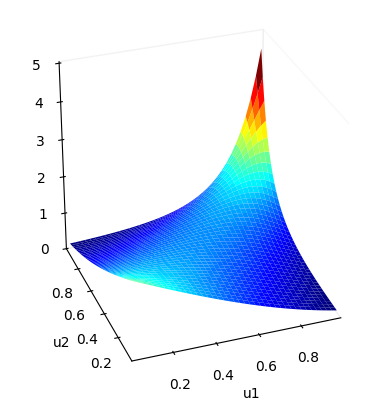

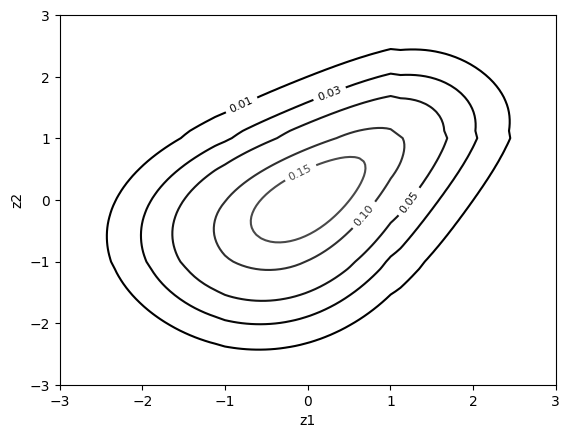

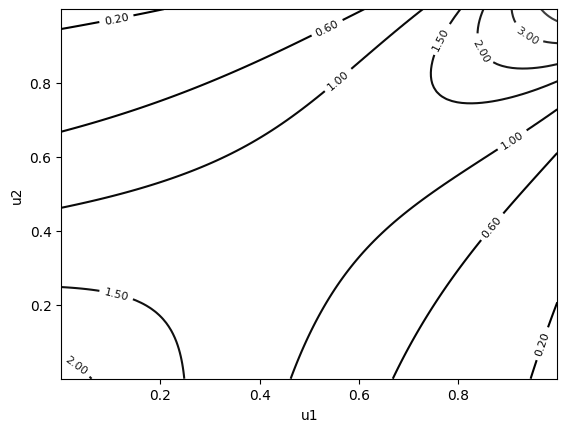

In [95]:
cop_all.plot()  # surface plot of copula density
cop_all.plot(type="contour", margin_type="norm")  # contour plot with normal margins
cop_all.plot(type="contour", margin_type="unif")  # contour plot of copula density


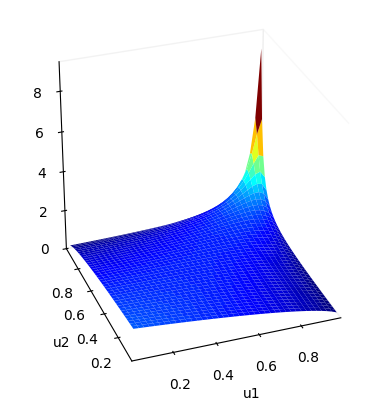

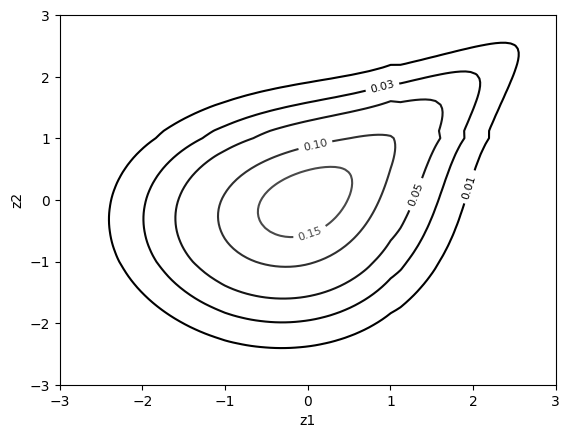

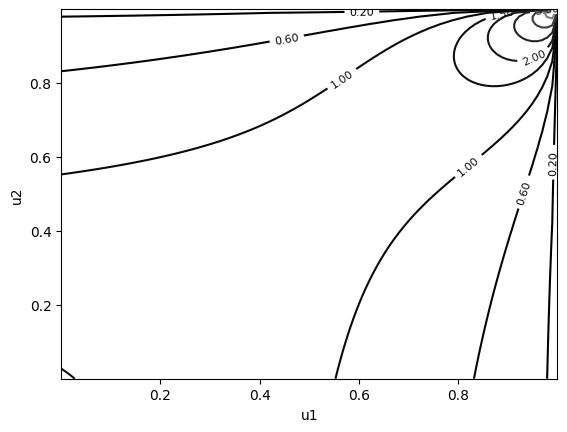

In [96]:
cop_fn.plot()  # surface plot of copula density
cop_fn.plot(type="contour", margin_type="norm")  # contour plot with normal margins
cop_fn.plot(type="contour", margin_type="unif")  # contour plot of copula density

In [97]:
print(
cop_fn.aic(),
cop_all.aic()
)

-60.787662443136156 -1568.0936341819636


In [98]:
xy_all

array([[20.3048901 ,  0.56453636],
       [19.3808111 ,  0.64179847],
       [20.57987069,  0.43692769],
       ...,
       [20.82978071,  0.7649074 ],
       [20.92045434,  0.61746757],
       [20.71224198,  0.64506643]], shape=(6377, 2))

In [99]:
test_input = np.array([[21, 1], [20, 0.5], [19, 0.1], [21.01, 1.9]])

In [100]:
mapped_marginals2norm(test_input,
                                 xy_all, 
                                 uv_all,
                                 u_inv=True)

array([[0.95403157, 0.65028863],
       [0.58914452, 0.08870215],
       [0.32634137, 0.0017989 ],
       [0.9580463 , 0.99979513]])

In [101]:
mapped_marginals2norm(test_input,
                                 xy_fn, 
                                 uv_fn,
                                 u_inv=True)

array([[0.83792467, 0.4181557 ],
       [0.22114648, 0.0475609 ],
       [0.06122187, 0.00676347],
       [0.8527981 , 0.99596718]])

In [102]:
def get_completeness(input_xy, cop_all, cop_fn, pi_fn, xy_all, uv_all, xy_fn, uv_fn):
    input_uv_all = mapped_marginals2norm(input_xy, xy_all, uv_all, u_inv=True)
    input_uv_fn  = mapped_marginals2norm(input_xy, xy_fn,  uv_fn,  u_inv=True)

    valid = ~np.isnan(input_uv_all).any(axis=1) & ~np.isnan(input_uv_fn).any(axis=1)

    completeness = np.full(len(input_xy), np.nan)

    if np.any(valid):
        den_all = cop_all.pdf(input_uv_all[valid])
        den_fn = cop_fn.pdf(input_uv_fn[valid])

        with np.errstate(divide="ignore", invalid="ignore"):
            vals = 1 - (den_fn * pi_fn) / den_all

        vals = np.clip(vals, 0, 1)
        vals[~np.isfinite(vals)] = np.nan
        completeness[valid] = vals

    # where completness is nan, set to 1 - the fn dataset is a subset
    # so we assume that the completeness is 1 outside theose regions
    completeness[np.isnan(completeness)] = 1.0
    return completeness

In [103]:
get_completeness(test_input, cop_all, cop_fn, pi_fn, xy_all, uv_all, xy_fn, uv_fn)

array([0.95388735, 0.91698358, 0.94315908, 0.99340387])

In [104]:
array = get_completeness(xy_all, cop_all, cop_fn, pi_fn, xy_all, uv_all, xy_fn, uv_fn)

In [105]:
print(np.nansum(array) / np.sum(~np.isnan(array)),
      (len(g09_valid) - len(g09_fn))/len(g09_valid)
)

# sum(array) / len(array)

0.9309095078083196 0.949349223772934


In [106]:
np.sum(np.isnan(array))

np.int64(0)

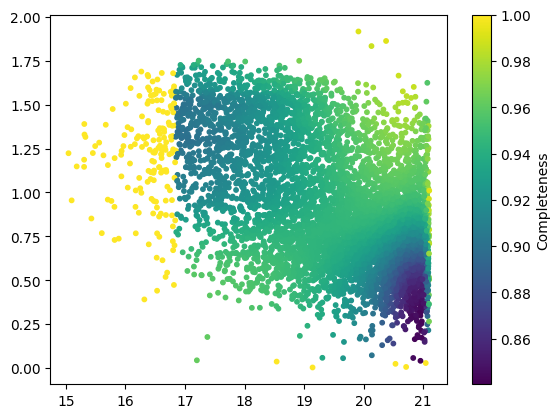

In [107]:
plt.scatter(xy_all[:, 0], xy_all[:, 1], c=array, cmap='viridis', s=10)
plt.colorbar(label='Completeness')

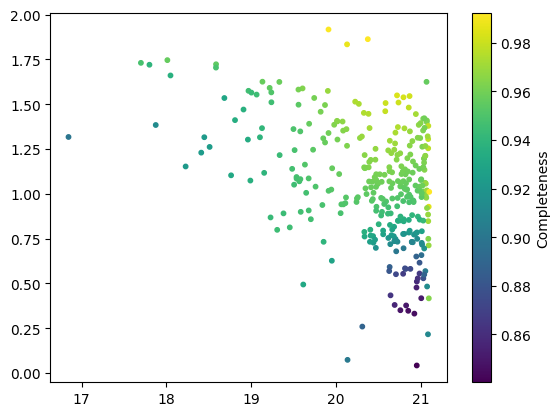

In [108]:
array_fn = get_completeness(xy_fn, cop_all, cop_fn, pi_fn, xy_all, uv_all, xy_fn, uv_fn)
plt.scatter(xy_fn[:, 0], xy_fn[:, 1], c=array_fn, cmap='viridis', s=10)
plt.colorbar(label='Completeness')

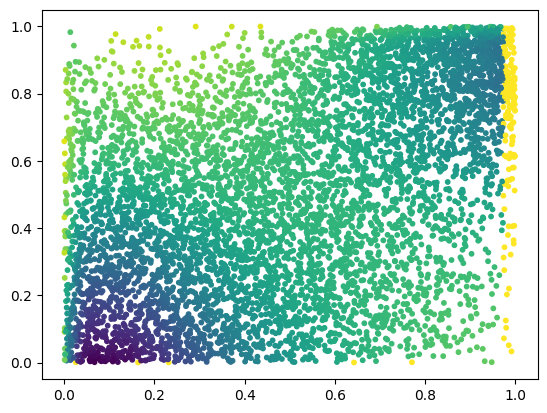

In [109]:
plt.scatter(uv_all[:, 0], uv_all[:, 1], c=array, cmap='viridis', s=10, label='All')

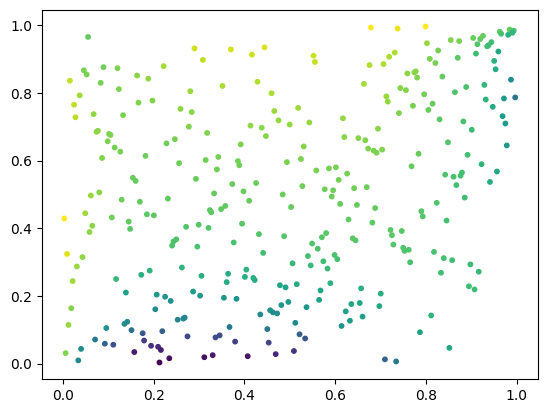

In [110]:
plt.scatter(uv_fn[:, 0], uv_fn[:, 1], c=array_fn, cmap='viridis', s=10, label='All')

In [111]:
from scipy.stats import gaussian_kde
kde_all = gaussian_kde(xy_all.T)
kde_fn  = gaussian_kde(xy_fn.T)

def get_completeness(input_xy, kde_all, kde_fn, pi_fn):
    den_all = kde_all(input_xy.T)
    den_fn  = kde_fn(input_xy.T)
    return np.clip(1 - (den_fn * pi_fn) / den_all, 0, 1)

In [113]:
test = get_completeness(xy_all, kde_all, kde_fn, pi_fn)

In [114]:
sum(test)/len(test)

np.float64(0.9514502869306439)

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_kde_contours(xy_all, xy_fn):
    """
    Plot 1: KDE contours for both samples overlaid on scatter data.
    Shows where the fn subsample sits relative to the full sample.
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    mag_grid = np.linspace(xy_all[:, 0].min(), xy_all[:, 0].max(), 100)
    col_grid = np.linspace(xy_all[:, 1].min(), xy_all[:, 1].max(), 100)
    M, C = np.meshgrid(mag_grid, col_grid)
    grid = np.vstack([M.ravel(), C.ravel()])

    kde_all = gaussian_kde(xy_all.T)
    kde_fn  = gaussian_kde(xy_fn.T)

    Z_all = kde_all(grid).reshape(M.shape)
    Z_fn  = kde_fn(grid).reshape(M.shape)

    ax.scatter(*xy_all.T, s=5, alpha=0.3, color='steelblue', label='full sample')
    ax.scatter(*xy_fn.T,  s=5, alpha=0.5, color='tomato',    label='fn sample')
    ax.contour(M, C, Z_all, levels=6, colors='steelblue', linewidths=1.0)
    ax.contour(M, C, Z_fn,  levels=6, colors='tomato',    linewidths=1.0, linestyles='--')

    ax.set_xlabel('mag_Zt')
    ax.set_ylabel('g-i')
    ax.legend(fontsize=9)
    ax.set_title('KDE contours: full vs fn sample')
    plt.tight_layout()
    plt.show()


def plot_completeness_map(xy_all, xy_fn, pi_fn):
    """
    Plot 2: Completeness heatmap across mag/colour space.
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    mag_grid = np.linspace(xy_all[:, 0].min(), xy_all[:, 0].max(), 100)
    col_grid = np.linspace(xy_all[:, 1].min(), xy_all[:, 1].max(), 100)
    M, C = np.meshgrid(mag_grid, col_grid)
    grid = np.vstack([M.ravel(), C.ravel()])

    kde_all = gaussian_kde(xy_all.T)
    kde_fn  = gaussian_kde(xy_fn.T)

    Z_all = kde_all(grid)
    Z_fn  = kde_fn(grid)

    with np.errstate(divide='ignore', invalid='ignore'):
        completeness = 1 - (Z_fn * pi_fn) / Z_all
    completeness = np.clip(completeness, 0, 1).reshape(M.shape)

    im = ax.pcolormesh(M, C, completeness, cmap='RdYlGn', vmin=0, vmax=1)
    ax.contour(M, C, completeness, levels=[0.5, 0.8, 0.9], colors='k',
               linewidths=0.8, linestyles='--')
    plt.colorbar(im, ax=ax, label='completeness')

    ax.set_xlabel('mag_Zt')
    ax.set_ylabel('g-i')
    ax.set_title('Estimated completeness')
    plt.tight_layout()
    plt.show()

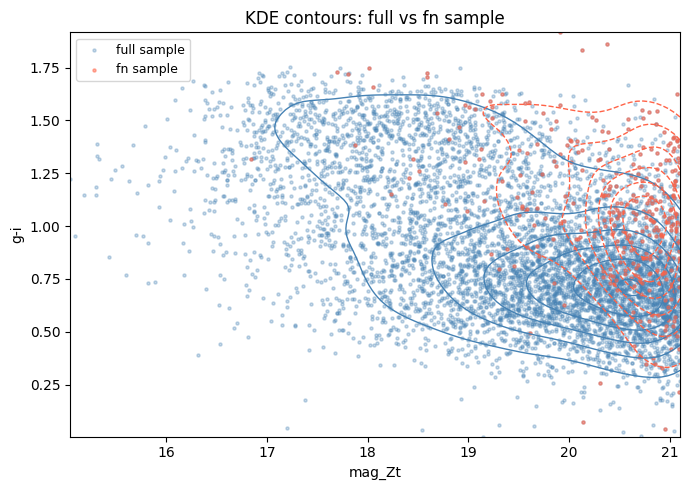

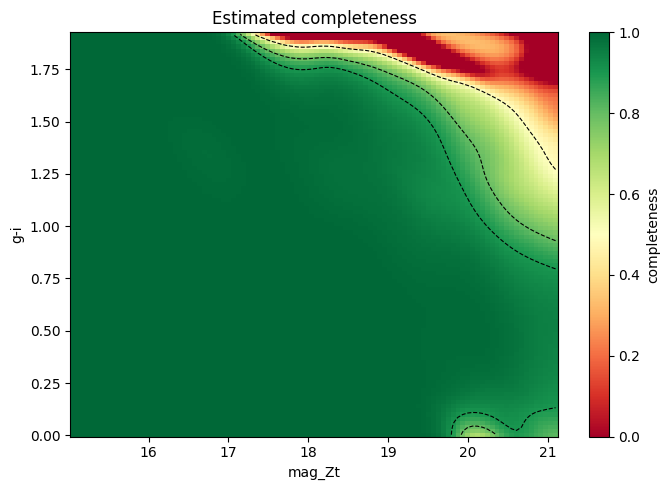

In [116]:
plot_kde_contours(xy_all, xy_fn)
plot_completeness_map(xy_all, xy_fn, pi_fn)

In [17]:
tp_labels = g09_valid['TP'].to_numpy()
fn_labels = g09_valid['FN'].to_numpy()

In [18]:
tp_labels

array([ True,  True,  True, ...,  True,  True,  True], shape=(6377,))

In [94]:
cop_tp = pv.Bicop(family=pv.bb8)
cop_tp.fit(uv_all)#[tp_labels])


In [95]:
cop_tp

<pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters = 2.7
0.8

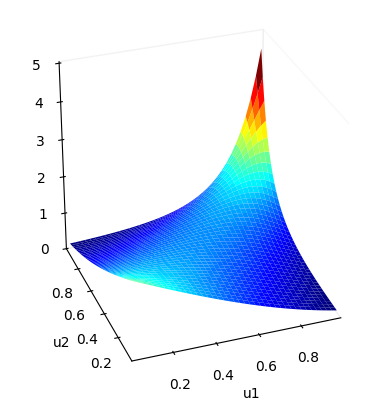

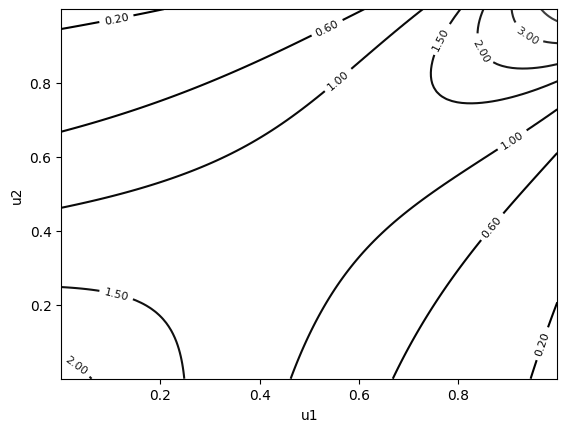

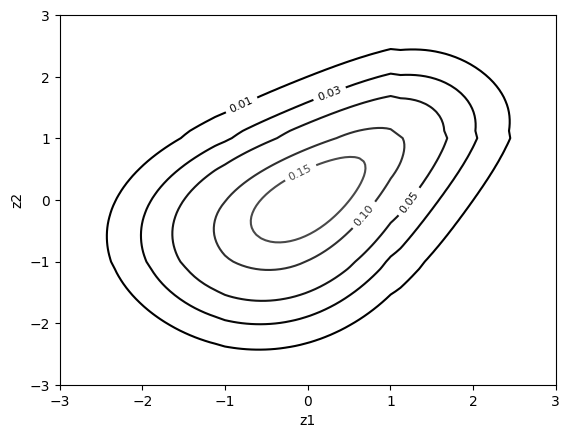

In [97]:
cop_tp.plot()  # surface plot of copula density
cop_tp.plot(type="contour", margin_type="unif")
cop_tp.plot(type="contour", margin_type="norm")

In [88]:
cop_fn = pv.Bicop(family=pv.bb8)
cop_fn.fit(uv_all[fn_labels])

In [89]:
len(uv_all[fn_labels])

323

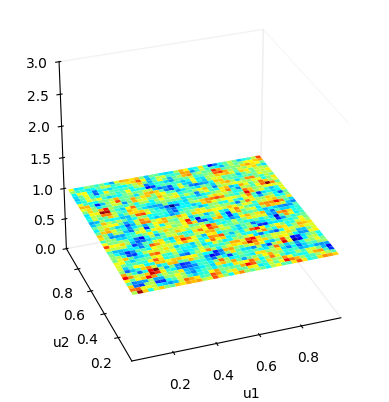

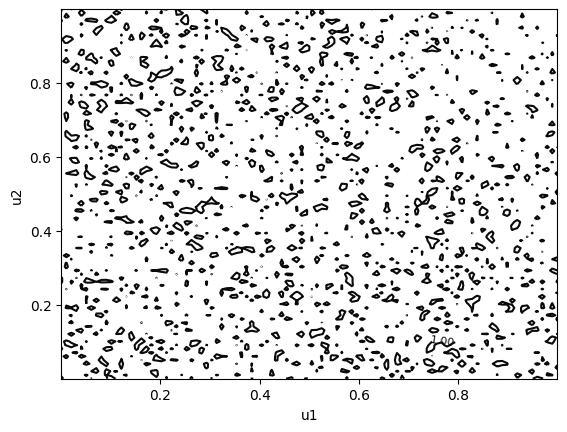

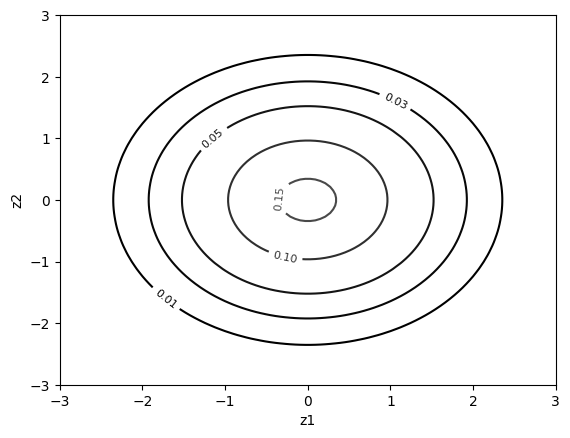

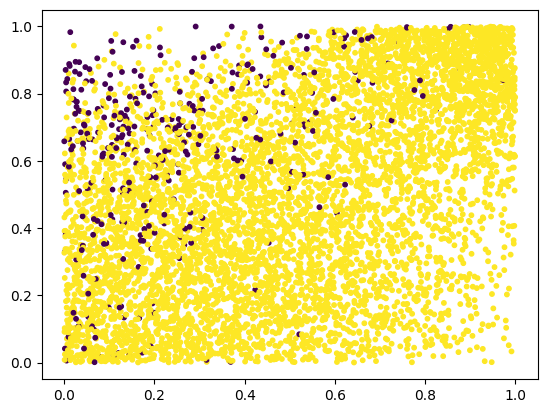

In [90]:
cop_fn.plot()  # surface plot of copula density
cop_fn.plot(type="contour", margin_type="unif")
cop_fn.plot(type="contour", margin_type="norm")
plt.scatter(uv_all[:, 0], uv_all[:, 1], c=tp_labels, s=10, label='All')

In [109]:
cop_tp

<pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters = 2.7
0.8

In [114]:
sims = cop_tp.simulate(8000)
pseudo_data = mapped_norm2marginals(sims, xy_all, u_inv=True)

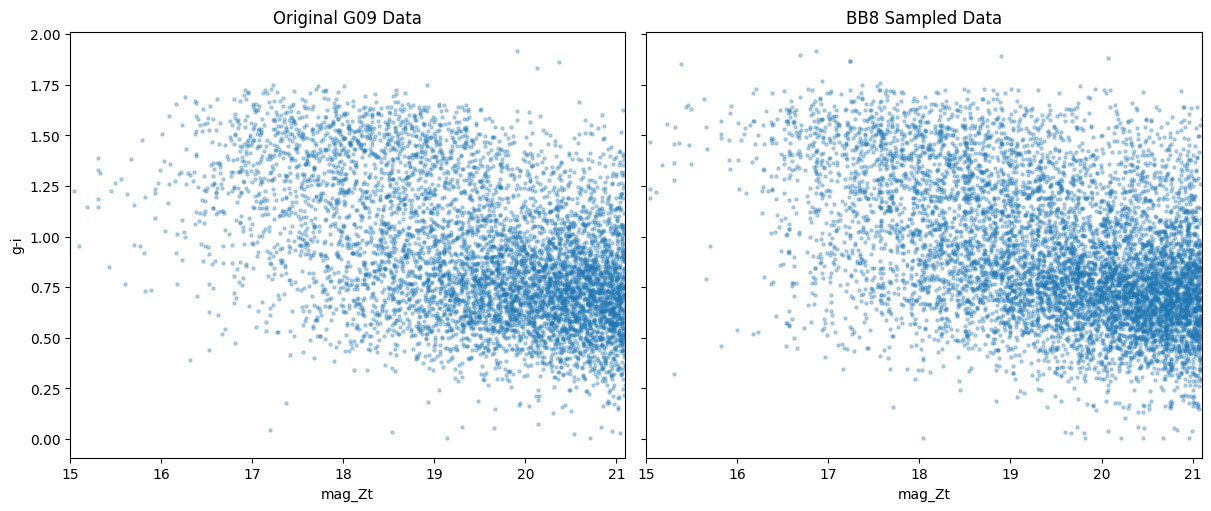

In [115]:
# figure with 2 subplots

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)

##plt.scatter(pseudo_data[:, 0], pseudo_data[:, 1], s=5, alpha=0.3)

axs[0].scatter(xy_all[:, 0], xy_all[:, 1], s=5, alpha=0.3)
axs[0].set_title('Original G09 Data')
axs[0].set_xlabel('mag_Zt')
axs[0].set_ylabel('g-i')
axs[0].set_xlim(15, 21.1)

axs[1].scatter(pseudo_data[:, 0], pseudo_data[:, 1], s=5, alpha=0.3)
axs[1].set_title('BB8 Sampled Data')
axs[1].set_xlabel('mag_Zt')
axs[1].set_xlim(15, 21.1)

plt.savefig('copula_sample_comparison.png', dpi=300)

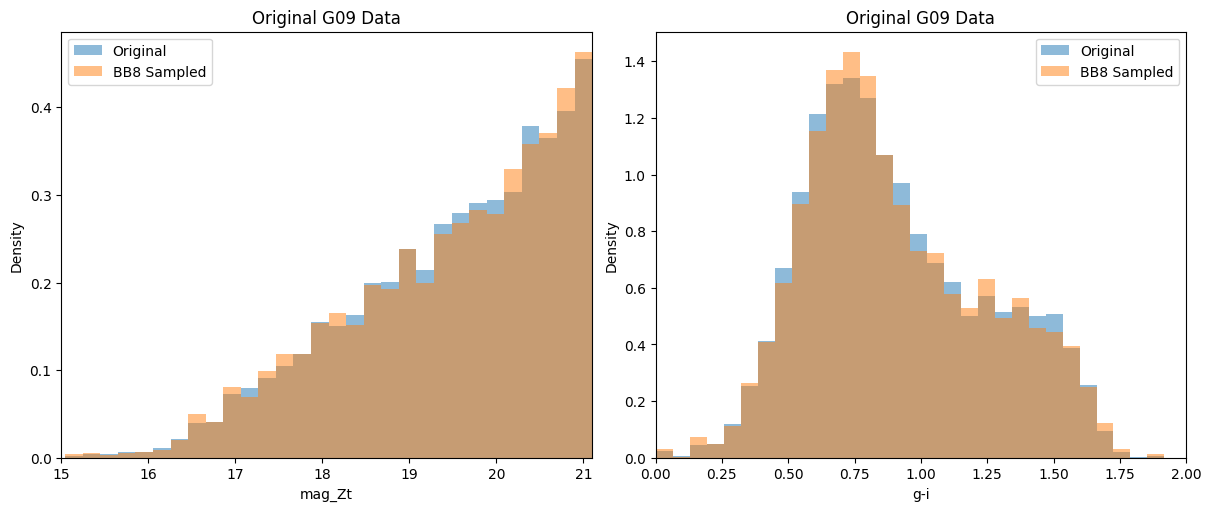

In [122]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axs[0].hist(xy_all[:, 0], bins=30, alpha=0.5, label='Original', density=True)
axs[0].hist(pseudo_data[:, 0], bins=30, alpha=0.5, label='BB8 Sampled', density=True)
axs[0].set_title('Original G09 Data')
axs[0].set_xlabel('mag_Zt')
axs[0].set_ylabel('Density')
axs[0].set_xlim(15, 21.1)
axs[0].legend()

axs[1].hist(xy_all[:, 1], bins=30, alpha=0.5, label='Original', density=True)
axs[1].hist(pseudo_data[:, 1], bins=30, alpha=0.5, label='BB8 Sampled', density=True)
axs[1].set_title('Original G09 Data')
axs[1].set_xlabel('g-i')
axs[1].set_ylabel('Density')
axs[1].set_xlim(0, 2)
axs[1].legend()

plt.savefig('copula_sample_marginals.png', dpi=300)

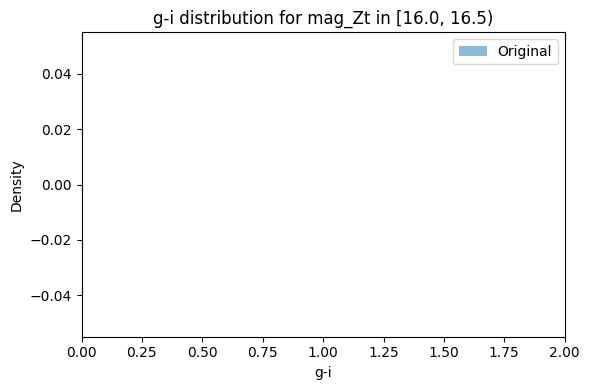

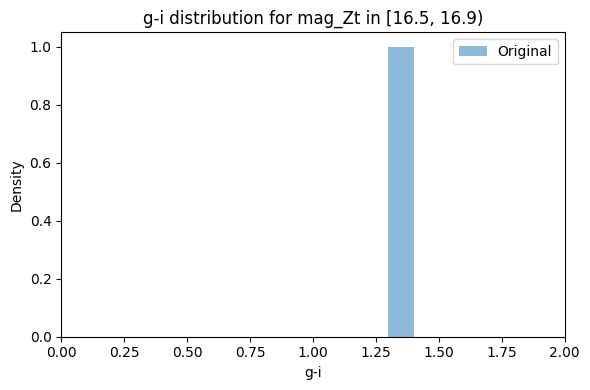

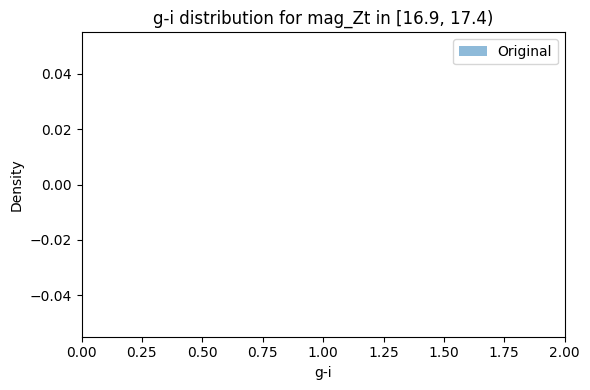

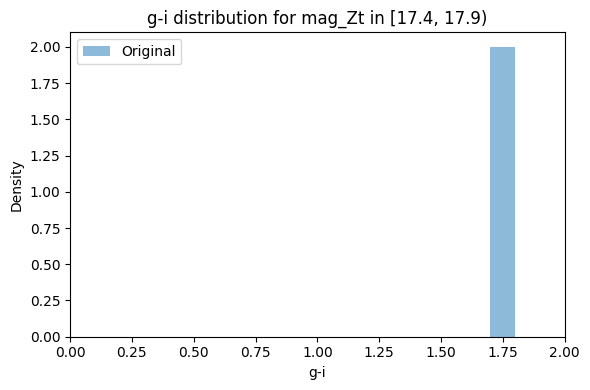

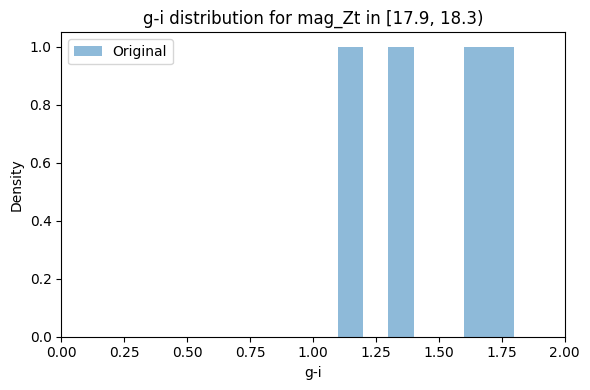

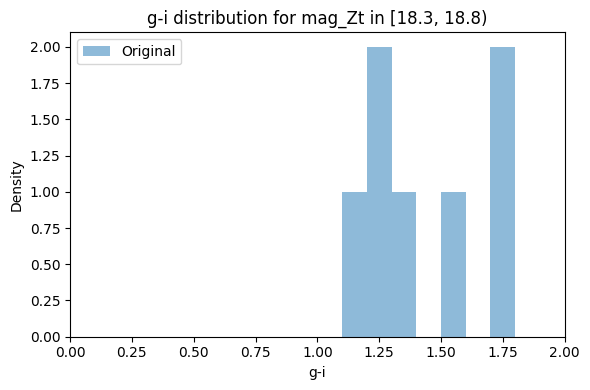

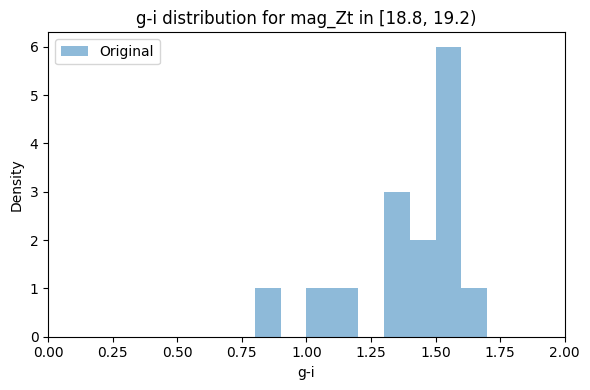

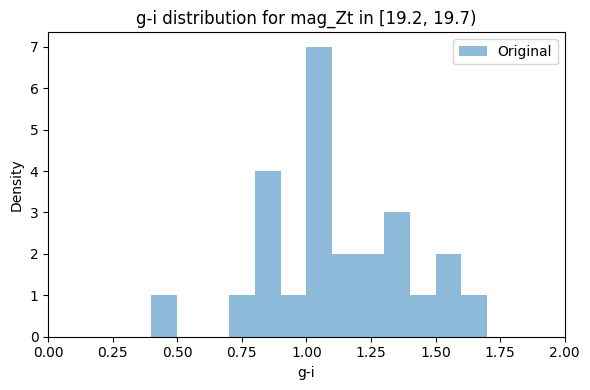

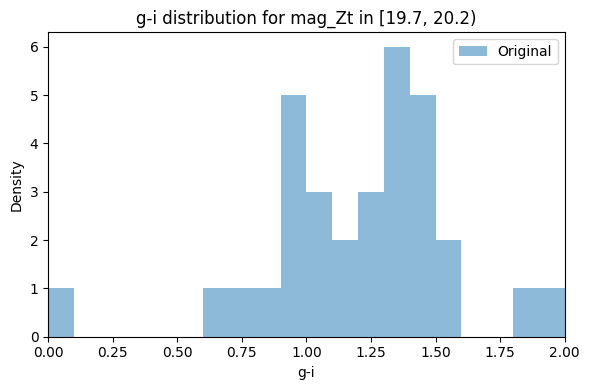

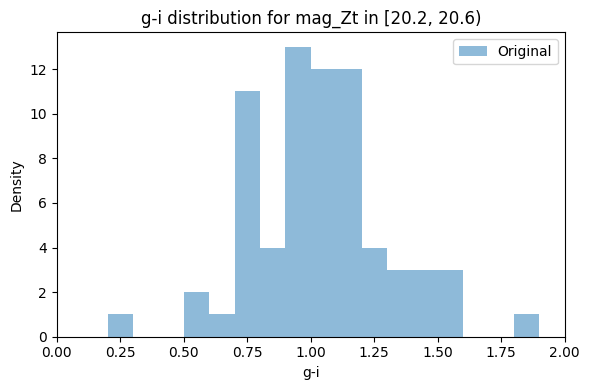

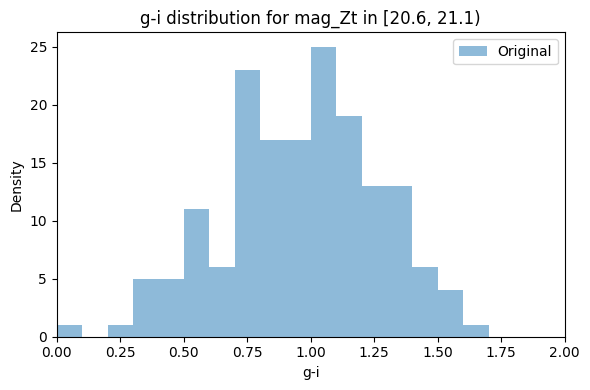

In [136]:
mag_slices = np.linspace(16, 21.1, 12)
bins = np.arange(0, 2.1, 0.1)
for mag_index in range(len(mag_slices) - 1):

    lower_bound = mag_slices[mag_index]
    upper_bound = mag_slices[mag_index + 1]
    data = xy_all[fn_labels]
    slice_all = data[(data[:, 0] >= mag_slices[mag_index]) & (data[:, 0] < mag_slices[mag_index + 1])]
    plt.figure(figsize=(6, 4))
    plt.hist(slice_all[:, 1], bins=bins, alpha=0.5, label='Original')
    plt.title(f'g-i distribution for mag_Zt in [{mag_slices[mag_index]:.1f}, {mag_slices[mag_index + 1]:.1f})')
    plt.xlabel('g-i')
    plt.ylabel('Density')
    plt.xlim(0, 2)
    plt.legend()
    plt.tight_layout()
    #plt.savefig(f'gi_distribution_mag_{mag:.1f}_{mag+0.5:.1f}.png', dpi=300)

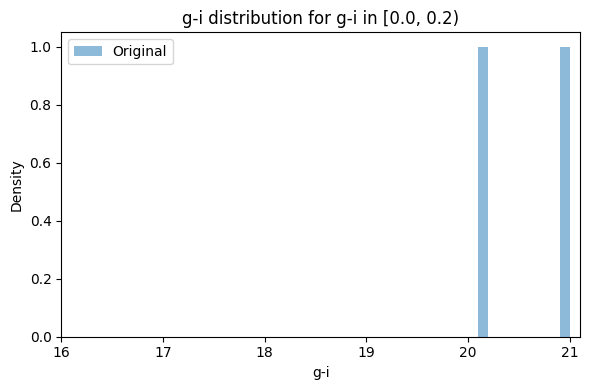

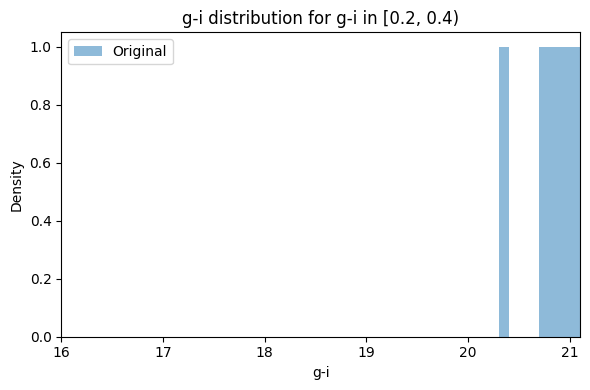

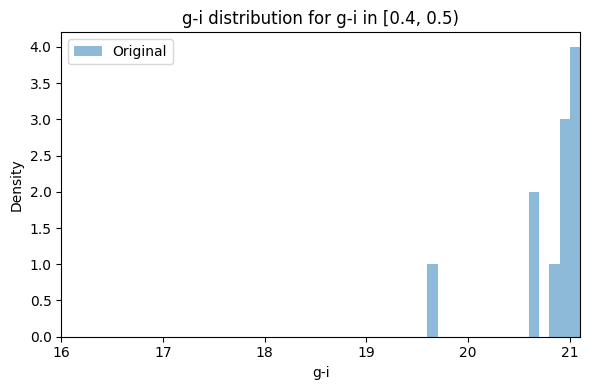

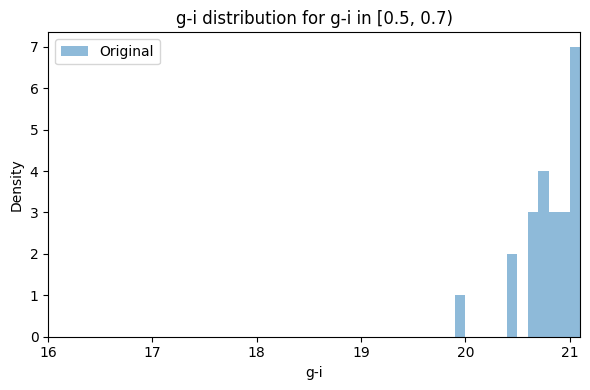

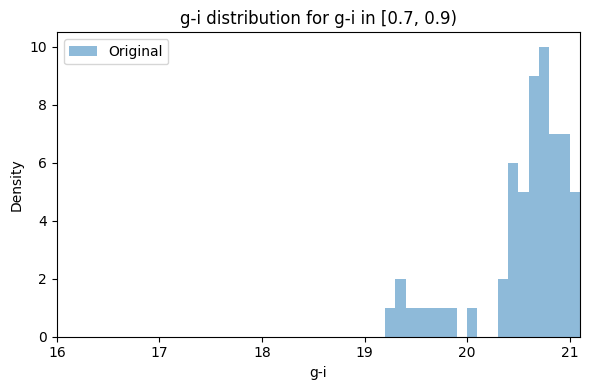

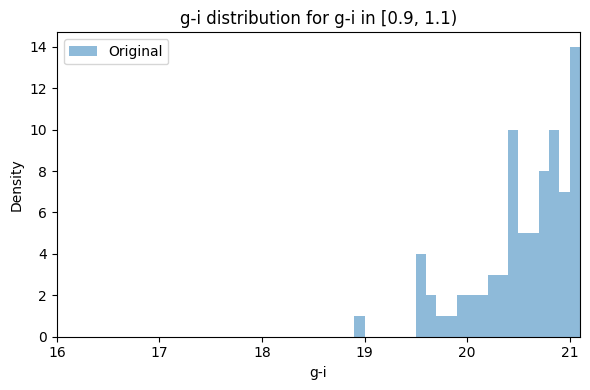

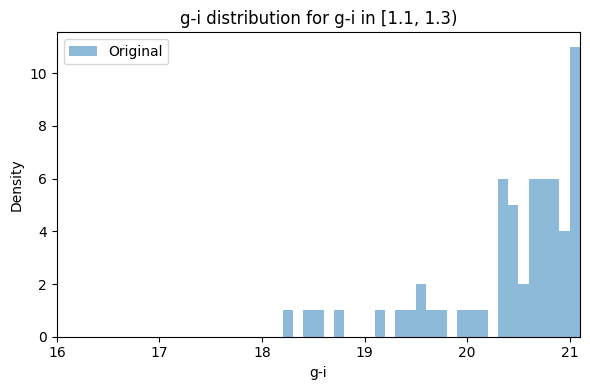

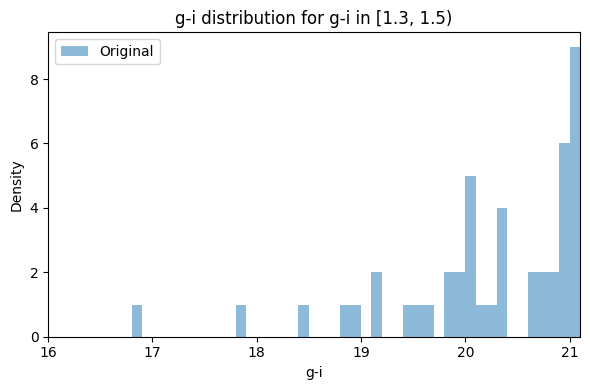

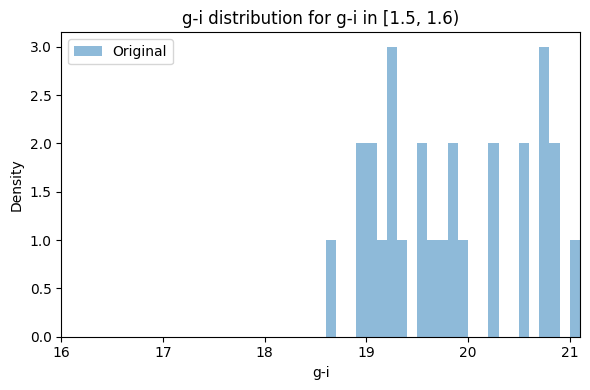

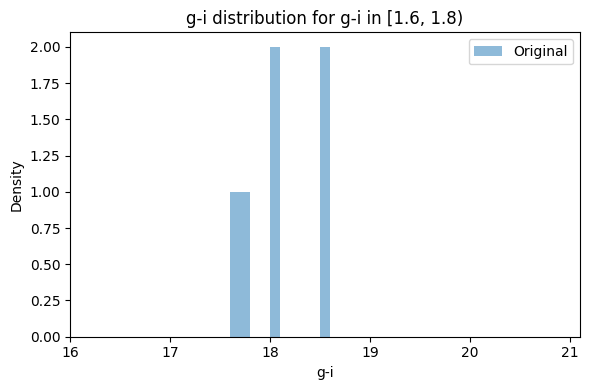

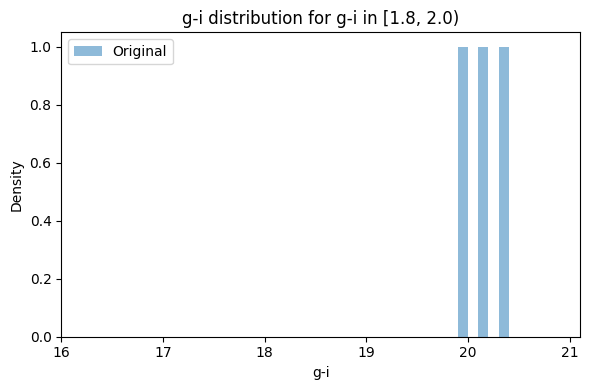

In [139]:
mag_slices = np.linspace(0, 2, 12)
bins = np.arange(16, 21.1, 0.1)
for mag_index in range(len(mag_slices) - 1):

    lower_bound = mag_slices[mag_index]
    upper_bound = mag_slices[mag_index + 1]
    data = xy_all[fn_labels]
    slice_all = data[(data[:, 1] >= mag_slices[mag_index]) & (data[:, 1] < mag_slices[mag_index + 1])]
    plt.figure(figsize=(6, 4))
    plt.hist(slice_all[:, 0], bins=bins, alpha=0.5, label='Original')
    plt.title(f'g-i distribution for g-i in [{mag_slices[mag_index]:.1f}, {mag_slices[mag_index + 1]:.1f})')
    plt.xlabel('g-i')
    plt.ylabel('Density')
    plt.xlim(16, 21.1)
    plt.legend()
    plt.tight_layout()
    #plt.savefig(f'gi_distribution_mag_{mag:.1f}_{mag+0.5:.1f}.png', dpi=300)

(16.0, 21.1)

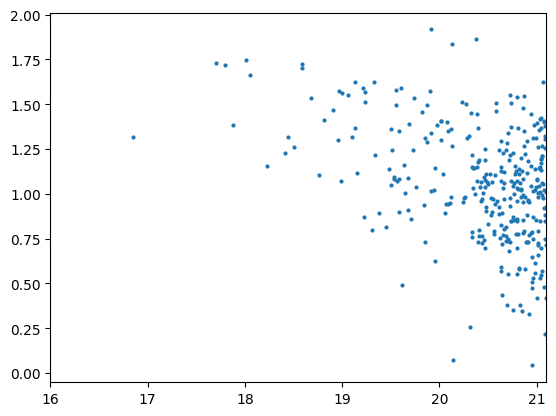

In [143]:
plt.scatter(xy_all[fn_labels][:, 0], xy_all[fn_labels][:, 1], s = 4)
plt.xlim(16, 21.1)

In [151]:
from scipy.stats import multivariate_normal

def double_gaussian_2d(xy, amp1, mx1, my1, sx1, sy1, rho1,
                            amp2, mx2, my2, sx2, sy2, rho2):
    """xy: (N, 2) array"""
    
    def bvn(xy, mx, my, sx, sy, rho):
        cov = [[sx**2, rho*sx*sy],
               [rho*sx*sy, sy**2]]
        return multivariate_normal(mean=[mx, my], cov=cov).pdf(xy)
    
    return amp1 * bvn(xy, mx1, my1, sx1, sy1, rho1) + \
           amp2 * bvn(xy, mx2, my2, sx2, sy2, rho2)

In [153]:
from scipy.optimize import minimize
from scipy.stats import multivariate_normal

def neg_log_likelihood(params, xy):
    amp1, mx1, my1, sx1, sy1, rho1, \
    amp2, mx2, my2, sx2, sy2, rho2 = params

    # Constrain params to valid ranges
    if any(s <= 0 for s in [sx1, sy1, sx2, sy2]):
        return np.inf
    if not (-1 < rho1 < 1 and -1 < rho2 < 1):
        return np.inf
    if amp1 <= 0 or amp2 <= 0:
        return np.inf

    cov1 = [[sx1**2, rho1*sx1*sy1], [rho1*sx1*sy1, sy1**2]]
    cov2 = [[sx2**2, rho2*sx2*sy2], [rho2*sx2*sy2, sy2**2]]

    # Mix weights must sum to 1 for a proper density
    w1 = amp1 / (amp1 + amp2)
    w2 = 1 - w1

    pdf = (w1 * multivariate_normal(mean=[mx1, my1], cov=cov1).pdf(xy) +
           w2 * multivariate_normal(mean=[mx2, my2], cov=cov2).pdf(xy))

    # Clip to avoid log(0)
    return -np.sum(np.log(np.clip(pdf, 1e-300, None)))

# Initial guess: [amp1, mx1, my1, sx1, sy1, rho1, amp2, mx2, my2, sx2, sy2, rho2]
p0 = [1, -1, -1, 1, 1, 0,
      1,  1,  1, 1, 1, 0]

result = minimize(neg_log_likelihood, p0, args=(xy_fn,), method='Nelder-Mead',
                  options={'maxiter': 10000, 'xatol': 1e-6})

params = result.x

LinAlgError: When `allow_singular is False`, the input matrix must be symmetric positive definite.

In [155]:
def neg_log_likelihood(params, xy):
    amp1, mx1, my1, sx1, sy1, rho1, \
    amp2, mx2, my2, sx2, sy2, rho2 = params

    # Strict validity checks
    if sx1 <= 0 or sy1 <= 0 or sx2 <= 0 or sy2 <= 0:
        return 1e10
    if not (-0.99 < rho1 < 0.99 and -0.99 < rho2 < 0.99):
        return 1e10
    if amp1 <= 0 or amp2 <= 0:
        return 1e10

    try:
        cov1 = [[sx1**2, rho1*sx1*sy1], [rho1*sx1*sy1, sy1**2]]
        cov2 = [[sx2**2, rho2*sx2*sy2], [rho2*sx2*sy2, sy2**2]]

        w1 = amp1 / (amp1 + amp2)
        w2 = 1 - w1

        pdf = (w1 * multivariate_normal(mean=[mx1, my1], cov=cov1).pdf(xy) +
               w2 * multivariate_normal(mean=[mx2, my2], cov=cov2).pdf(xy))

        return -np.sum(np.log(np.clip(pdf, 1e-300, None)))

    except np.linalg.LinAlgError:
        return 1e10

In [157]:
# Data-driven init: split by median x and estimate each half
mid = np.median(xy_fn[:, 0])
left  = xy_fn[xy_fn[:, 0] <  mid]
right = xy_fn[xy_fn[:, 0] >= mid]

p0 = [
    1, left[:,0].mean(),  left[:,1].mean(),  left[:,0].std(),  left[:,1].std(),  0,
    1, right[:,0].mean(), right[:,1].mean(), right[:,0].std(), right[:,1].std(), 0,
]

result = minimize(neg_log_likelihood, p0, args=(xy_fn,), method='Nelder-Mead',
                  options={'maxiter': 20000, 'xatol': 1e-6, 'fatol': 1e-6})

In [161]:
result.x

array([ 3.59439504e+01,  1.97041551e+01,  1.22586039e+00,  7.79163118e-01,
        3.00655126e-01, -3.75404325e-01,  6.36635520e+01,  2.07920621e+01,
        9.60322774e-01,  2.21885154e-01,  2.92352214e-01,  2.19001501e-02])

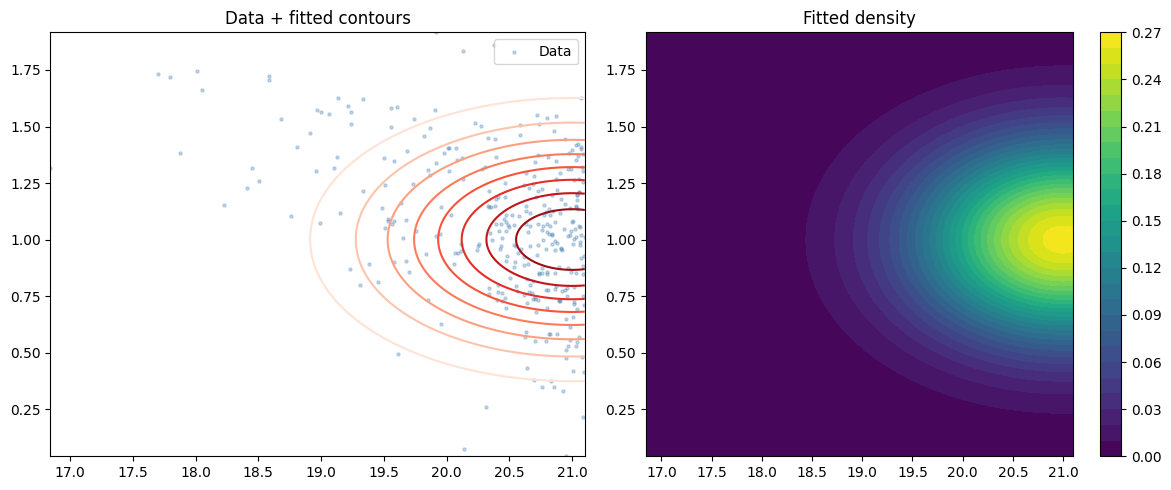

In [182]:
amp1, mx1, my1, sx1, sy1, rho1, amp2, mx2, my2, sx2, sy2, rho2 = result.x

w1 = amp1 / (amp1 + amp2)
w2 = 1 - w1

cov1 = [[sx1**2, rho1*sx1*sy1], [rho1*sx1*sy1, sy1**2]]
cov2 = [[sx2**2, rho2*sx2*sy2], [rho2*sx2*sy2, sy2**2]]

# Evaluate fitted density on a grid
x_grid = np.linspace(xy_fn[:,0].min(), xy_fn[:,0].max(), 200)
y_grid = np.linspace(xy_fn[:,1].min(), xy_fn[:,1].max(), 200)
xx, yy = np.meshgrid(x_grid, y_grid)
grid = np.c_[xx.ravel(), yy.ravel()]

density = (w1 * multivariate_normal(mean=[mx1, my1], cov=cov1).pdf(grid) +
           w2 * multivariate_normal(mean=[mx2, my2], cov=cov2).pdf(grid)
          ).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: data + contours
axes[0].scatter(xy_fn[:,0], xy_fn[:,1], s=5, alpha=0.3, color='steelblue', label='Data')
axes[0].contour(xx, yy, density, levels=8, cmap='Reds')
axes[0].set_title('Data + fitted contours')
axes[0].legend()

# Right: fitted density heatmap
im = axes[1].contourf(xx, yy, density, levels=30, cmap='viridis')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Fitted density')

plt.tight_layout()
plt.show()

In [166]:
from scipy.stats import multivariate_normal
from scipy.integrate import dblquad

def truncated_norm_constant(means, cov, x_max=21.1, y_max=2.0):
    """Probability mass within the truncation region."""
    mv = multivariate_normal(mean=means, cov=cov)
    mass, _ = dblquad(
        lambda y, x: mv.pdf([x, y]),
        -np.inf, x_max,   # x limits
        -np.inf, y_max,   # y limits
    )
    return mass


from scipy.stats import multivariate_normal

def truncated_norm_constant_fast(mean, cov, x_max=21.1, y_max=2.0):
    """Uses marginal CDFs — exact for axis-aligned, approximate otherwise."""
    mv = multivariate_normal(mean=mean, cov=cov)
    # P(X < x_max, Y < y_max) via CDF
    return mv.cdf([x_max, y_max])

def neg_log_likelihood_truncated(params, xy, x_max=21.1, y_max=2.0):
    amp1, mx1, my1, sx1, sy1, rho1, \
    amp2, mx2, my2, sx2, sy2, rho2 = params

    if sx1 <= 0 or sy1 <= 0 or sx2 <= 0 or sy2 <= 0:
        return 1e10
    if not (-0.99 < rho1 < 0.99 and -0.99 < rho2 < 0.99):
        return 1e10
    if amp1 <= 0 or amp2 <= 0:
        return 1e10

    try:
        cov1 = [[sx1**2, rho1*sx1*sy1], [rho1*sx1*sy1, sy1**2]]
        cov2 = [[sx2**2, rho2*sx2*sy2], [rho2*sx2*sy2, sy2**2]]

        w1 = amp1 / (amp1 + amp2)
        w2 = 1 - w1

        # Normalisation constants: how much mass is inside the window
        Z1 = truncated_norm_constant_fast([mx1, my1], cov1, x_max, y_max)
        Z2 = truncated_norm_constant_fast([mx2, my2], cov2, x_max, y_max)

        if Z1 < 1e-10 or Z2 < 1e-10:
            return 1e10

        mv1 = multivariate_normal(mean=[mx1, my1], cov=cov1)
        mv2 = multivariate_normal(mean=[mx2, my2], cov=cov2)

        # Truncated mixture density at each point
        pdf = w1 * mv1.pdf(xy) / Z1 + w2 * mv2.pdf(xy) / Z2

        return -np.sum(np.log(np.clip(pdf, 1e-300, None)))

    except np.linalg.LinAlgError:
        return 1e10

In [170]:
# Data-driven init: split by median x and estimate each half
mid = np.median(xy_fn[:, 0])
left  = xy_fn[xy_fn[:, 0] <  mid]
right = xy_fn[xy_fn[:, 0] >= mid]

p0 = [
    1, left[:,0].mean(),  left[:,1].mean(),  left[:,0].std(),  left[:,1].std(),  0,
    1, right[:,0].mean(), right[:,1].mean(), right[:,0].std(), right[:,1].std(), 0,
]

result = minimize(neg_log_likelihood_truncated, p0, args=(xy_fn,), method='Nelder-Mead',
                  options={'maxiter': 20000, 'xatol': 1e-6, 'fatol': 1e-6})

In [231]:
p0 = [
    # amp   mx      my     sx    sy    rho
      0.5,  21.2,   1.0,   1.0,  0.3,  -0,   # component 1 (right)
      0.5,  23.0,   1.5,   4.0,  0.4, -0.6,   # component 2 (off-right, tilted)
]

bounds = [
    (0.1, 0.9),          # amp1
    (21.1, 25),       # mx1
    (0.8, 2),       # my1 # 0.9
    (0.5, 5),       # sx1
    (0.1, 1),       # sy1
    (-0.9, 0.1),      # rho1
# AMP 2
    (0.1, 0.9),          # amp1
    (21.1, 25),       # mx1
    (0.9, 2),       # my1
    (0.5, 5),       # sx1
    (0.1, 1),       # sy1
    (-0.9, 0.1),      # rho1
]

result = minimize(
    neg_log_likelihood_truncated, p0, args=(xy_fn,),
    method='L-BFGS-B', bounds=bounds,
    options={'maxiter': 10000}
)

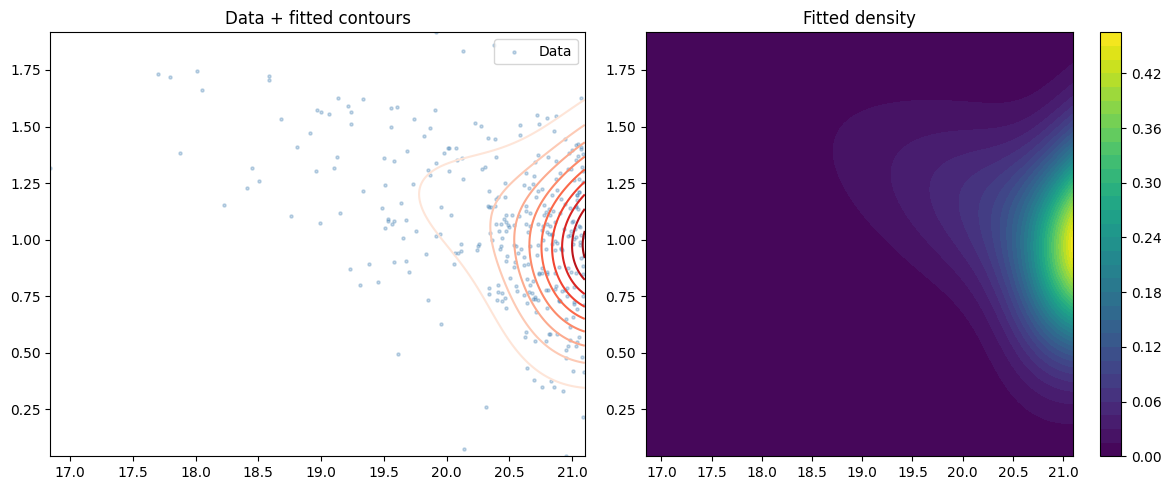

In [248]:
p0 = [
    # amp   mx      my     sx    sy    rho
      0.5,  22,   1.0,   1.0,  0.5,  0.0,   # component 1 Main
      0.3,  23.0,   1.,   3.0,  0.4, -0.80,   # component 2 stragglers
]


bounds = [
    (0.1, 0.99),          # amp1
    (21.1, 25),       # mx1
    (0.5, 2),       # my1
    (0.3, 5),       # sx1 # 0.5 
    (0.05, 1),       # sy1 # 0.1
    (-0.9, 0.9),      # rho1
# AMP 2
    (0.1, 0.99),          # amp1
    (21.1, 25),       # mx1
    (0.5, 2),       # my1
    (0.5, 5),       # sx1
    (0.1, 1),       # sy1
    (-0.9, 0.1),      # rho1
]

result = minimize(
    neg_log_likelihood_truncated, p0, args=(xy_fn,),
    method='L-BFGS-B', bounds=bounds,
    options={'maxiter': 10000}
)


amp1, mx1, my1, sx1, sy1, rho1, amp2, mx2, my2, sx2, sy2, rho2 = result.x #0 #result.x

w1 = amp1 / (amp1 + amp2)
w2 = 1 - w1

cov1 = [[sx1**2, rho1*sx1*sy1], [rho1*sx1*sy1, sy1**2]]
cov2 = [[sx2**2, rho2*sx2*sy2], [rho2*sx2*sy2, sy2**2]]

# Evaluate fitted density on a grid
x_grid = np.linspace(xy_fn[:,0].min(), xy_fn[:,0].max(), 200)
y_grid = np.linspace(xy_fn[:,1].min(), xy_fn[:,1].max(), 200)
xx, yy = np.meshgrid(x_grid, y_grid)
grid = np.c_[xx.ravel(), yy.ravel()]

density = (w1 * multivariate_normal(mean=[mx1, my1], cov=cov1).pdf(grid) +
           w2 * multivariate_normal(mean=[mx2, my2], cov=cov2).pdf(grid)
          ).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: data + contours
axes[0].scatter(xy_fn[:,0], xy_fn[:,1], s=5, alpha=0.3, color='steelblue', label='Data')
axes[0].contour(xx, yy, density, levels=10, cmap='Reds')
axes[0].set_title('Data + fitted contours')
axes[0].legend()

# Right: fitted density heatmap
im = axes[1].contourf(xx, yy, density, levels=30, cmap='viridis')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Fitted density')

plt.tight_layout()
plt.show()

In [249]:
result.x

array([ 0.24979439, 21.39368494,  1.0554361 ,  0.44937979,  0.33328167,
        0.32206385,  0.44643699, 22.83048858,  0.65958917,  1.78589804,
        0.41448408, -0.76567864])

In [250]:
x_t = np.log(21.1 - xy_fn[:, 0])   # maps (-∞, 21.1] → ℝ
y_t = np.log(2.0  - xy_fn[:, 1])   # maps (-∞, 2.0]  → ℝ

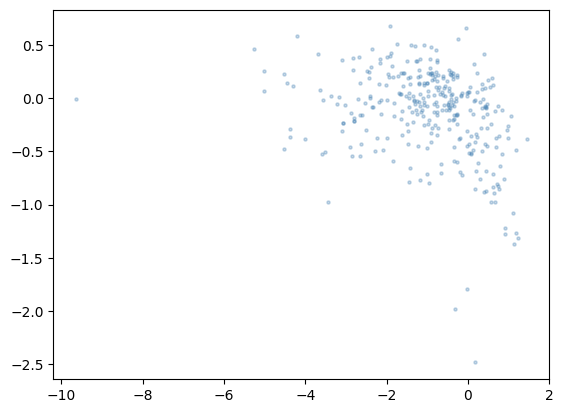

In [252]:
plt.scatter(x_t, y_t, s=5, alpha=0.3, color='steelblue', label='Data')

Fitting K=1...
  AIC=1446.96  BIC=1465.84  χ²=50.97  p=0.000
Fitting K=2...
  AIC=1331.51  BIC=1373.06  χ²=13.09  p=0.011
Fitting K=3...
  AIC=1289.81  BIC=1354.03  χ²=nan  p=nan
Fitting K=4...
  AIC=1266.88  BIC=1353.77  χ²=nan  p=nan
Fitting K=5...
  AIC=1260.59  BIC=1370.14  χ²=nan  p=nan


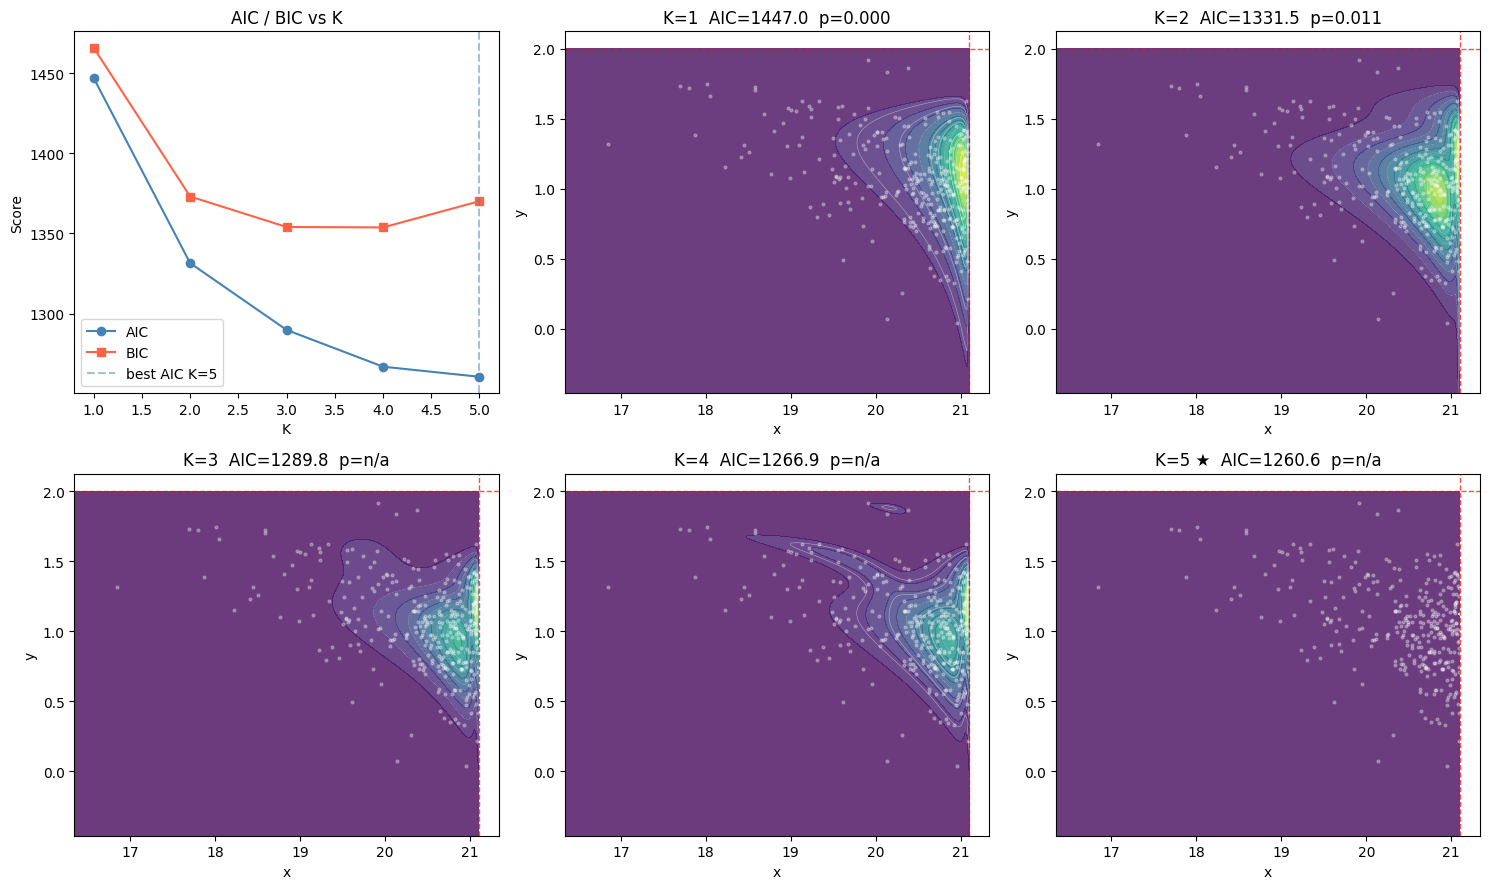

In [256]:
# ── Transforms (with boundary guard) ─────────────────────────────────────────

def transform(xy, x_max=21.1, y_max=2.0, eps=1e-8):
    """Clip points away from boundary before log transform."""
    x_clipped = np.clip(xy[:, 0], -np.inf, x_max - eps)
    y_clipped = np.clip(xy[:, 1], -np.inf, y_max - eps)
    xt = np.log(x_max - x_clipped)
    yt = np.log(y_max - y_clipped)
    return np.column_stack([xt, yt])

def filter_boundary(xy, x_max=21.1, y_max=2.0, eps=1e-8):
    """Remove points at or beyond the boundary (shouldn't exist but just in case)."""
    mask = (xy[:, 0] < x_max - eps) & (xy[:, 1] < y_max - eps)
    n_removed = (~mask).sum()
    if n_removed > 0:
        print(f"Warning: removed {n_removed} points at/beyond boundary")
    return xy[mask]

# ── GoF test (fixed dof) ──────────────────────────────────────────────────────

# ── GMM likelihood ────────────────────────────────────────────────────────────

def unpack_params(params, k):
    """Unpack flat param vector into weights, means, covariances."""
    weights, means, covs = [], [], []
    idx = 0
    raw_weights = params[:k];  idx = k
    weights = np.exp(raw_weights) / np.sum(np.exp(raw_weights))  # softmax
    for _ in range(k):
        mx, my = params[idx], params[idx+1];  idx += 2
        sx, sy = np.exp(params[idx]), np.exp(params[idx+1]);  idx += 2  # log-parameterised
        rho = np.tanh(params[idx]);  idx += 1  # tanh keeps rho in (-1, 1)
        cov = [[sx**2, rho*sx*sy], [rho*sx*sy, sy**2]]
        means.append([mx, my])
        covs.append(cov)
    return weights, means, covs


def log_jacobian(xy, x_max=21.1, y_max=2.0):
    """log |det J| = -log(x_max - x) - log(y_max - y), summed over data"""
    return -np.sum(np.log(x_max - xy[:, 0])) - np.sum(np.log(y_max - xy[:, 1]))


def n_params(k):
    # k weights (minus 1 for sum-to-1) + k*(2 means + 2 scales + 1 rho)
    return (k - 1) + k * 5

def neg_log_likelihood(params, xy_t, k):
    try:
        weights, means, covs = unpack_params(params, k)
        pdf = sum(w * multivariate_normal(mean=m, cov=c).pdf(xy_t)
                  for w, m, c in zip(weights, means, covs))
        return -np.sum(np.log(np.clip(pdf, 1e-300, None)))
    except np.linalg.LinAlgError:
        return 1e10

def total_neg_log_likelihood(params, xy_t, xy_orig, k):
    """NLL in transformed space + log-Jacobian correction."""
    return neg_log_likelihood(params, xy_t, k) + log_jacobian(xy_orig)

def gof_test(xy_t, weights, means, covs, n_estimated_params, n_bins=10):
    """
    Chi² GoF on a regular grid in transformed space.
    Use more bins (10x10=100 cells) so dof stays positive for higher K.
    Merge low-expected cells into an 'other' bin rather than dropping them.
    """
    x_edges = np.linspace(xy_t[:,0].min(), xy_t[:,0].max(), n_bins+1)
    y_edges = np.linspace(xy_t[:,1].min(), xy_t[:,1].max(), n_bins+1)
    observed, _, _ = np.histogram2d(xy_t[:,0], xy_t[:,1], bins=[x_edges, y_edges])

    # Expected counts
    expected = np.zeros_like(observed, dtype=float)
    for i in range(n_bins):
        for j in range(n_bins):
            x0, x1 = x_edges[i], x_edges[i+1]
            y0, y1 = y_edges[j], y_edges[j+1]
            cell_prob = 0.0
            for w, m, c in zip(weights, means, covs):
                mv = multivariate_normal(mean=m, cov=c)
                cell_prob += w * (mv.cdf([x1, y1]) - mv.cdf([x1, y0])
                                - mv.cdf([x0, y1]) + mv.cdf([x0, y0]))
            expected[i, j] = cell_prob * len(xy_t)

    # Merge cells with expected < 5 into a single "other" bin
    mask = expected >= 5
    chi2_stat = np.sum((observed[mask] - expected[mask])**2 / expected[mask])

    # Add merged "other" bin if there are any low-count cells
    if (~mask).sum() > 0:
        obs_other = observed[~mask].sum()
        exp_other = expected[~mask].sum()
        if exp_other >= 5:
            chi2_stat += (obs_other - exp_other)**2 / exp_other
            n_cells = mask.sum() + 1
        else:
            n_cells = mask.sum()
    else:
        n_cells = mask.sum()

    dof = n_cells - 1 - n_estimated_params
    if dof <= 0:
        print(f"  Warning: dof={dof} ≤ 0, too few bins for K={len(weights)}. "
              f"GoF test not reliable — increase n_bins or n_data.")
        return np.nan, np.nan

    p_val = 1 - chi2.cdf(chi2_stat, dof)
    return chi2_stat, p_val

# ── Plot (fixed grid boundary) ────────────────────────────────────────────────

def plot_results(xy_orig, results, x_max=21.1, y_max=2.0, eps=1e-3):
    best_aic = min(results, key=lambda r: r['aic'])
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    # AIC/BIC summary
    ax = axes[0]
    ks   = [r['k']   for r in results]
    aics = [r['aic'] for r in results]
    bics = [r['bic'] for r in results]
    ax.plot(ks, aics, 'o-', label='AIC', color='steelblue')
    ax.plot(ks, bics, 's-', label='BIC', color='tomato')
    ax.axvline(best_aic['k'], color='steelblue', linestyle='--', alpha=0.5, label=f"best AIC K={best_aic['k']}")
    ax.set_xlabel('K'); ax.set_ylabel('Score'); ax.set_title('AIC / BIC vs K')
    ax.legend()

    # Grid strictly inside boundary
    x_grid = np.linspace(xy_orig[:,0].min() - 0.5, x_max - eps, 200)
    y_grid = np.linspace(xy_orig[:,1].min() - 0.5, y_max - eps, 200)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_orig = np.c_[xx.ravel(), yy.ravel()]
    grid_t    = transform(grid_orig, x_max, y_max, eps=0)  # already inside boundary

    for i, r in enumerate(results):
        ax = axes[i + 1]
        pdf_t = sum(w * multivariate_normal(mean=m, cov=c).pdf(grid_t)
                    for w, m, c in zip(r['weights'], r['means'], r['covs']))
        jac      = 1.0 / ((x_max - grid_orig[:,0]) * (y_max - grid_orig[:,1]))
        pdf_orig = (pdf_t * jac).reshape(xx.shape)

        ax.contourf(xx, yy, pdf_orig, levels=20, cmap='viridis', alpha=0.8)
        ax.contour( xx, yy, pdf_orig, levels=10, colors='white', linewidths=0.4, alpha=0.5)
        ax.scatter(xy_orig[:,0], xy_orig[:,1], s=4, alpha=0.3, color='white')
        ax.axvline(x_max, color='red', linestyle='--', lw=1, alpha=0.7)
        ax.axhline(y_max, color='red', linestyle='--', lw=1, alpha=0.7)

        star = ' ★' if r['k'] == best_aic['k'] else ''
        gof_str = f"p={r['gof_p']:.3f}" if not np.isnan(r['gof_p']) else "p=n/a"
        ax.set_title(f"K={r['k']}{star}  AIC={r['aic']:.1f}  {gof_str}")
        ax.set_xlabel('x'); ax.set_ylabel('y')

    plt.tight_layout()
    plt.show()


def fit_gmm(xy_orig, k, n_restarts=5, x_max=21.1, y_max=2.0):
    xy_t = transform(xy_orig, x_max, y_max)
    best = None

    for _ in range(n_restarts):
        # Random init from data scatter
        idx = np.random.choice(len(xy_t), k, replace=False)
        p0 = []
        p0 += [0.0] * k                                          # log weights (uniform)
        for i in range(k):
            p0 += [xy_t[idx[i], 0], xy_t[idx[i], 1]]            # means
            p0 += [np.log(xy_t[:, 0].std()), np.log(xy_t[:, 1].std())]  # log sigmas
            p0 += [0.0]                                           # arctanh(rho) = 0

        result = minimize(
            neg_log_likelihood, p0, args=(xy_t, k),
            method='L-BFGS-B',
            options={'maxiter': 10000, 'ftol': 1e-12}
        )
        if best is None or result.fun < best.fun:
            best = result

    nll = best.fun
    p   = n_params(k)
    n   = len(xy_orig)
    aic = 2 * nll + 2 * p
    bic = 2 * nll + p * np.log(n)

    # DoF-weighted chi² goodness-of-fit
    # Bin transformed data, compare observed vs expected counts
    weights, means, covs = unpack_params(best.x, k)
    gof_stat, gof_p = gof_test(xy_t, weights, means, covs, p)

    return {
        'k': k, 'params': best.x, 'nll': nll,
        'aic': aic, 'bic': bic,
        'gof_stat': gof_stat, 'gof_p': gof_p,
        'weights': weights, 'means': means, 'covs': covs,
        'n_params': p
    }


def fit_all(xy_orig, k_range=range(1, 6), x_max=21.1, y_max=2.0):
    results = []
    for k in k_range:
        print(f"Fitting K={k}...")
        r = fit_gmm(xy_orig, k, x_max=x_max, y_max=y_max)
        print(f"  AIC={r['aic']:.2f}  BIC={r['bic']:.2f}  "
              f"χ²={r['gof_stat']:.2f}  p={r['gof_p']:.3f}")
        results.append(r)
    return results
# ── Run ───────────────────────────────────────────────────────────────────────

xy_clean  = filter_boundary(xy_fn)
results   = fit_all(xy_clean)
plot_results(xy_clean, results)

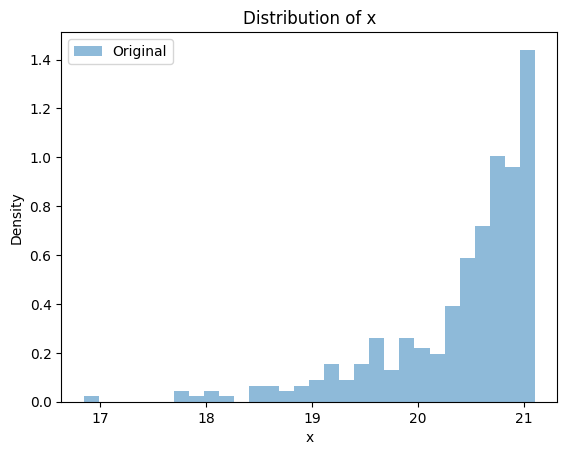

In [257]:
plt.hist(xy_fn[:, 0], bins=30, alpha=0.5, label='Original', density=True)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Distribution of x')
plt.legend()
plt.show()

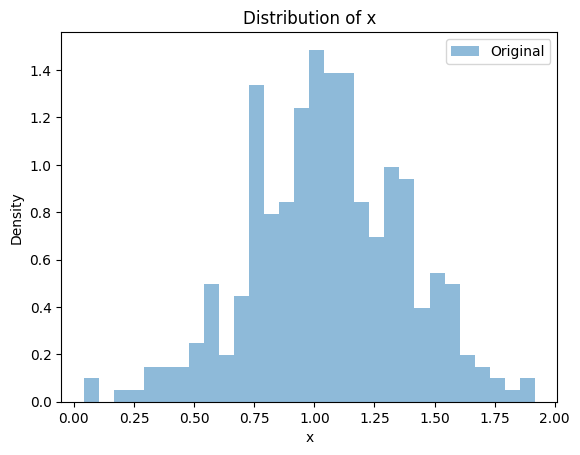

In [258]:
plt.hist(xy_fn[:, 1], bins=30, alpha=0.5, label='Original', density=True)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Distribution of x')
plt.legend()
plt.show()